In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [1]:
uncapped_short = pd.DataFrame(columns = ["job", "deltaG"])
uncapped_long = pd.DataFrame(columns = ["job", "deltaG"])
for i in range(0,35):
    path = f"/home/kunzj/energy_calculation/mmpbsa_calc_correct_files/whole_binder/job_{i +1}/test_results_energy_delta.csv"

    cutoff_first = 40# 10 - 200

    chunk = 400
    df_deltea = pd.read_csv(path, header = 1)
    mean_long = df_deltea.iloc[cutoff_first :, -1].mean()
    mean = df_deltea.iloc[cutoff_first :chunk, -1].mean()
    uncapped_short = pd.concat([uncapped_short, pd.DataFrame({"job": [str(i + 1)], "deltaG": [mean]})], ignore_index=True)
    uncapped_long = pd.concat([uncapped_long, pd.DataFrame({"job": [str(i + 1)], "deltaG": [mean_long]})], ignore_index = True)

r, p = stats.pearsonr(uncapped_long.deltaG[0:35].astype(float), uncapped_short.deltaG[0:35].astype(float))

plt.text(0.05, 0.95, f"r = {r:.2f}, p = {p:.3f}", transform=plt.gca().transAxes, verticalalignment='top')

plt.scatter(uncapped_long.deltaG[0:35],uncapped_short.deltaG[0:35])
plt.xlabel("MMPBSA based on frames from full 50ns simulation starting from same frame")
plt.ylabel(f"MMPBSA based on frames from {cutoff_first /40} ns to {chunk/40} ns")



NameError: name 'pd' is not defined

In [21]:
first = pd.read_csv("/home/kunzj/report/data/first_df_metrics_md_sim.csv")
second = pd.read_csv("/home/kunzj/report/data/second_df_metrics_md_sim.csv")
third = pd.read_csv("/home/kunzj/report/data/third_df_metrics_md_sim.csv")
first_new_version = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/j_1/md_sim_analysis/mmpbsa/jobs/delta_total_summary.csv")

first_new_version = first_new_version.sort_values("subdir", key=lambda s: s.str.extract(r'(\d+)$')[0].astype(int))
first_new_version # MISSING: 38, 43, 44, 48

,subdir,delta_total
0,job_1,-60.90
11,job_2,-64.59
22,job_3,-60.15
32,job_4,-62.57
40,job_5,-66.39
43,job_6,-80.90
44,job_7,-64.12
45,job_8,-69.15
46,job_9,-71.26
1,job_10,-70.47


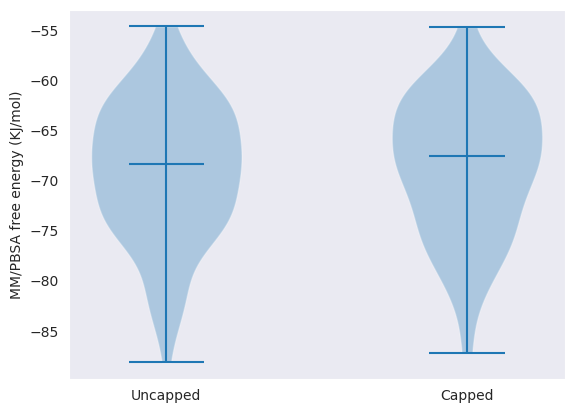

In [11]:

plt.violinplot([first.mmpbsa,first_new_version.delta_total  ], showmedians = True)
plt.grid(False)
plt.xticks([1,2],["Uncapped", "Capped"],rotation=0)

plt.ylabel("MM/PBSA free energy (KJ/mol)")


plt.show()

In [20]:
first_new_version.delta_total.iloc[0:49]

0    -60.90
11   -64.59
22   -60.15
32   -62.57
40   -66.39
43   -80.90
44   -64.12
45   -69.15
46   -71.26
1    -70.47
2    -72.22
3    -67.00
4    -61.17
5    -60.98
6    -67.36
7    -76.60
8    -67.25
9    -74.46
10   -62.57
12   -74.47
13   -73.14
14   -87.22
15   -79.19
16   -77.27
17   -68.34
18   -68.67
19   -61.47
20   -61.72
21   -59.93
23   -76.37
24   -76.70
25   -62.04
26   -67.56
27   -61.38
28   -69.11
29   -69.56
30   -67.41
31   -61.34
33   -64.12
34   -81.00
35   -69.00
36   -75.10
37   -72.61
38   -65.27
39   -65.38
41   -54.73
42   -75.70
Name: delta_total, dtype: float64

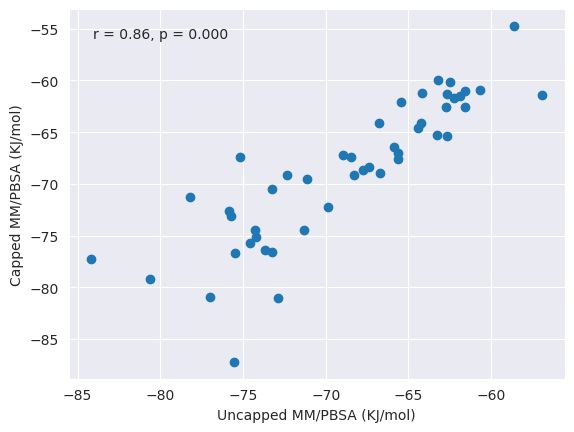

In [95]:
from scipy import stats

# Merge by job number to handle missing jobs (38, 43, 44, 48)
first_indexed = first.copy()
first_indexed["subdir"] = [f"job_{i+1}" for i in range(len(first_indexed))]


r, p = stats.pearsonr(merged["mmpbsa"], merged["delta_total"])

plt.scatter(merged["mmpbsa"], merged["delta_total"])
plt.xlabel("Uncapped MM/PBSA (KJ/mol)")
plt.ylabel("Capped MM/PBSA (KJ/mol)")
plt.text(0.05, 0.95, f"r = {r:.2f}, p = {p:.3f}", transform=plt.gca().transAxes, verticalalignment='top')
plt.show()